# Exercise - Stripping Caps


#### Notation Commands

$$\newcommand{\Black}{\mathcal{B}}
\newcommand{\Blackcall}{\Black_{\mathrm{call}}}
\newcommand{\Blackput}{\Black_{\mathrm{put}}}
\newcommand{\EcondS}{\hat{S}_{\mathrm{conditional}}}
\newcommand{\Efwd}{\mathbb{E}^{T}}
\newcommand{\Ern}{\mathbb{E}^{\mathbb{Q}}}
\newcommand{\Tfwd}{T_{\mathrm{fwd}}}
\newcommand{\Tunder}{T_{\mathrm{bond}}}
\newcommand{\accint}{A}
\newcommand{\carry}{\widetilde{\cpn}}
\newcommand{\cashflow}{C}
\newcommand{\convert}{\phi}
\newcommand{\cpn}{c}
\newcommand{\ctd}{\mathrm{CTD}}
\newcommand{\disc}{Z}
\newcommand{\done}{d_{1}}
\newcommand{\dt}{\Delta t}
\newcommand{\dtwo}{d_{2}}
\newcommand{\flatvol}{\sigma_{\mathrm{flat}}}
\newcommand{\flatvolT}{\sigma_{\mathrm{flat},T}}
\newcommand{\float}{\mathrm{flt}}
\newcommand{\freq}{m}
\newcommand{\futprice}{\mathcal{F}(t,T)}
\newcommand{\futpriceDT}{\mathcal{F}(t+h,T)}
\newcommand{\futpriceT}{\mathcal{F}(T,T)}
\newcommand{\futrate}{\mathscr{f}}
\newcommand{\fwdprice}{F(t,T)}
\newcommand{\fwdpriceDT}{F(t+h,T)}
\newcommand{\fwdpriceT}{F(T,T)}
\newcommand{\fwdrate}{f}
\newcommand{\fwdvol}{\sigma_{\mathrm{fwd}}}
\newcommand{\fwdvolTi}{\sigma_{\mathrm{fwd},T_i}}
\newcommand{\grossbasis}{B}
\newcommand{\hedge}{\Delta}
\newcommand{\ivol}{\sigma_{\mathrm{imp}}}
\newcommand{\logprice}{p}
\newcommand{\logyield}{y}
\newcommand{\mat}{(n)}
\newcommand{\nargcond}{d_{1}}
\newcommand{\nargexer}{d_{2}}
\newcommand{\netbasis}{\tilde{\grossbasis}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\notional}{K}
\newcommand{\pfwd}{P_{\mathrm{fwd}}}
\newcommand{\pnl}{\Pi}
\newcommand{\price}{P}
\newcommand{\probexer}{\hat{\mathcal{P}}_{\mathrm{exercise}}}
\newcommand{\pvstrike}{K^*}
\newcommand{\refrate}{r^{\mathrm{ref}}}
\newcommand{\rrepo}{r^{\mathrm{repo}}}
\newcommand{\spotrate}{r}
\newcommand{\spread}{s}
\newcommand{\strike}{K}
\newcommand{\swap}{\mathrm{sw}}
\newcommand{\swaprate}{\cpn_{\swap}}
\newcommand{\tbond}{\mathrm{fix}}
\newcommand{\ttm}{\tau}
\newcommand{\value}{V}
\newcommand{\vega}{\nu}
\newcommand{\years}{\tau}
\newcommand{\yearsACT}{\tau_{\mathrm{act/360}}}
\newcommand{\yield}{Y}$$


# 1. Pricing Floors


### Data

The file `data/cap_curves_2025-06-30.xlsx` has market data on the following curves:
* swap rates (SOFR)
* discount factors
* forward rates 
* flat volatilites

A few details
* the swap and forward rates are quarterly compounded.
* the flat volatilites are (Black) quotes on caps containing caplets ranging from expiration of $\tau=.5$ to $\tau=T$.


In [1]:
import os

import numpy as np
import pandas as pd

from scipy.stats import norm

from scipy.optimize import minimize
from scipy.optimize import brentq

import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r'data/cap_curves_2025-06-30.xlsx')
df['fixing'] = df['tenor'] - 0.25

display(df)

,tenor,swap rates,spot rates,discounts,forwards,flat vols,fwd vols,fixing
0,0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN,0.00
1,0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842,0.25
2,0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708,0.50
3,1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464,0.75
4,1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341,1.00
5,1.50,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521,1.25
6,1.75,0.034942,0.034868,0.941054,0.030542,0.285885,0.336809,1.50
7,2.00,0.034453,0.034374,0.933835,0.030919,0.295615,0.328654,1.75
8,2.25,0.034000,0.033916,0.926827,0.030248,0.299596,0.312413,2.00
9,2.50,0.033750,0.033665,0.919605,0.031414,0.299589,0.296022,2.25


In [3]:
def blacks_call_option_price(F, K, Z, sigma, T):

    # Blacks formula
    d1 = (np.log(F / K) + (0.5 * np.pow(sigma, 2) * T)) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma * np.sqrt(T))

    call_option_price = Z * (F * norm.cdf(d1) - K * norm.cdf(d2))

    return call_option_price

def blacks_put_option_price(F, K, Z, sigma, T):

    # Blacks formula
    d1 = (np.log(F / K) + (0.5 * np.pow(sigma, 2) * T)) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma * np.sqrt(T))

    put_option_price = Z * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

    return put_option_price

In [4]:
# Compounding frequency
n = 4

### 1.1.

Recall that a floor is a portfolio of floorlets which
* depend on the realized interest rate one quarter before the expiration.
* each have the same strike interest rate.

Use Black's formula to price **just one floorlet**
* expiring at `T=3`
* struck at the `T=3` swap rate
* notional of `100`
* quarterly frequency


In [5]:
floorlet = df.loc[df['tenor']==3].iloc[0]

F = floorlet['forwards']
K = floorlet['swap rates']

Z = floorlet['discounts']

sigma = floorlet['fwd vols']
T = floorlet['fixing']

floorlet_price = (100/n) * blacks_put_option_price(F, K, Z, sigma, T)

print(f"Floorlet price with expiry at 3Yr and Strike at {K:6f} = {floorlet_price:6f}")

Floorlet price with expiry at 3Yr and Strike at 0.033568 = 0.142948


### 1.2.

Use Black's formula to price the entire floor with expiration of `T=3`.

The floor has floorlets at `quarterly` frequency, except the first quarter.


In [6]:
floor = df.loc[(df['tenor'] >= 0.5) & (df['tenor'] <= 3)]
K = floor['swap rates'].iloc[-1]

floor_price = 0
for idx, floorlet in floor.iterrows():
    expiry = floorlet.loc['tenor']

    F = floorlet.loc['forwards']

    Z = floorlet.loc['discounts']

    sigma = floorlet.loc['fwd vols']
    T = floorlet.loc['fixing']

    floorlet_price = (100/n) * blacks_put_option_price(F, K, Z, sigma, T)
    print(f"Floorlet price with expiry at {expiry}Yr and Strike at {K:.6f} = {floorlet_price:.6f}")

    floor_price += floorlet_price

print('='*50)
print(f"Floor price with expiry at 3Yr and Strike at {K:6f} as sum of individual floorlets with fwd vols = {floor_price:.6f}")

Floorlet price with expiry at 0.5Yr and Strike at 0.033568 = 0.000551
Floorlet price with expiry at 0.75Yr and Strike at 0.033568 = 0.021385
Floorlet price with expiry at 1.0Yr and Strike at 0.033568 = 0.060129
Floorlet price with expiry at 1.25Yr and Strike at 0.033568 = 0.134934
Floorlet price with expiry at 1.5Yr and Strike at 0.033568 = 0.156063
Floorlet price with expiry at 1.75Yr and Strike at 0.033568 = 0.161993
Floorlet price with expiry at 2.0Yr and Strike at 0.033568 = 0.162743
Floorlet price with expiry at 2.25Yr and Strike at 0.033568 = 0.171241
Floorlet price with expiry at 2.5Yr and Strike at 0.033568 = 0.157445
Floorlet price with expiry at 2.75Yr and Strike at 0.033568 = 0.148123
Floorlet price with expiry at 3.0Yr and Strike at 0.033568 = 0.142948
Floor price with expiry at 3Yr and Strike at 0.033568 as sum of individual floorlets with fwd vols = 1.317555


In [7]:
floor = df.loc[(df['tenor'] >= 0.5) & (df['tenor'] <= 3)]
K = floor['swap rates'].iloc[-1]
sigma_flat = floor['flat vols'].iloc[-1]

floor_price = 0
for idx, floorlet in floor.iterrows():

    F = floorlet.loc['forwards']

    Z = floorlet.loc['discounts']

    T = floorlet.loc['fixing']

    floorlet_price_flat_vol = (100/n) * blacks_put_option_price(F, K, Z, sigma_flat, T)

    floor_price += floorlet_price_flat_vol

print('='*50)
print(f"Floor price with expiry at 3Yr and Strike at {K:6f} as sum of individual floorlets with flat vol = {floor_price:.6f}")

Floor price with expiry at 3Yr and Strike at 0.033568 as sum of individual floorlets with flat vol = 1.317555


# 2. Stripping Caps


### Data

Continue with the file `data/cap_curves_2025-06-30.xlsx`.


### 2.1 Cap Prices

For each cap maturity, $.5\le T \le 10$, use the flat volatility to get the price of the cap.

Report the cap prices across expirations, $.5\le T \le 10$.

Plot the cap prices across expirations.


In [8]:
caps_till_10yr = df.loc[(df['tenor'] >= 0.5) & (df['tenor'] <= 10)]

cap_prices = []
for idx, cap in caps_till_10yr.iterrows():
    K = cap['swap rates']
    sigma_flat = cap['flat vols']
    expiry = cap['tenor']

    cap_price = 0
    for idx, caplet in caps_till_10yr.iterrows():
        expiry_caplet = caplet.loc['tenor']
        if expiry_caplet > expiry:
            break

        F = caplet.loc['forwards']

        Z = caplet.loc['discounts']

        T = caplet.loc['fixing']

        caplet_price_flat_vol = (100/n) * blacks_call_option_price(F, K, Z, sigma_flat, T)

        cap_price += caplet_price_flat_vol

    cap_prices.append([expiry, cap_price])

cap_prices = pd.DataFrame(cap_prices, columns=['tenor', 'cap_price'])

display(cap_prices)

,tenor,cap_price
0,0.50,0.015719
1,0.75,0.053574
2,1.00,0.115339
3,1.25,0.214448
4,1.50,0.327791
5,1.75,0.450402
6,2.00,0.578409
7,2.25,0.705708
8,2.50,0.834493
9,2.75,0.964974


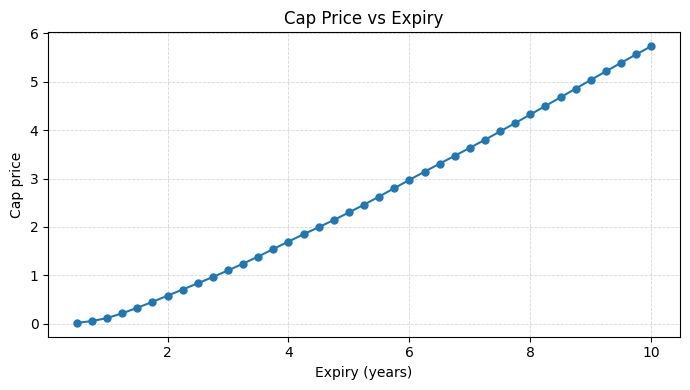

In [9]:
# plot cap_price vs expiry
cp = cap_prices.sort_values('tenor')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cp['tenor'], cp['cap_price'], marker='o', linestyle='-', linewidth=1.5, markersize=5)

ax.set_title('Cap Price vs Expiry')
ax.set_xlabel('Expiry (years)')
ax.set_ylabel('Cap price')
ax.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.show()

### 2.2 Caplet Prices and Forward Volatilities

Using the cap prices, strip out the
* caplet prices
* forward volatility at $\tau$ which properly prices caplet $\tau$ using Black's formula.

List and plot the forward volatility versus the flat volatiltiy.


In [10]:
caplets_till_10yr = pd.merge(caps_till_10yr, cap_prices, on='tenor')

caplets_till_10yr['caplet_price'] = np.nan
caplets_till_10yr['fwd vols calc'] = np.nan

caplets_till_10yr = caplets_till_10yr.set_index('tenor')

display(caplets_till_10yr)

,swap rates,spot rates,discounts,forwards,flat vols,fwd vols,fixing,cap_price,caplet_price,fwd vols calc
tenor,,,,,,,,,,
0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842,0.25,0.015719,NaN,NaN
0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708,0.50,0.053574,NaN,NaN
1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464,0.75,0.115339,NaN,NaN
1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341,1.00,0.214448,NaN,NaN
1.50,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521,1.25,0.327791,NaN,NaN
1.75,0.034942,0.034868,0.941054,0.030542,0.285885,0.336809,1.50,0.450402,NaN,NaN
2.00,0.034453,0.034374,0.933835,0.030919,0.295615,0.328654,1.75,0.578409,NaN,NaN
2.25,0.034000,0.033916,0.926827,0.030248,0.299596,0.312413,2.00,0.705708,NaN,NaN
2.50,0.033750,0.033665,0.919605,0.031414,0.299589,0.296022,2.25,0.834493,NaN,NaN


In [11]:
def root_func(sigma, F, K, Z, T, target_price):
    # We want this to equal 0
    return blacks_call_option_price(F, K, Z, sigma, T) - ((n/100) * target_price)

# Bootstrapping caplet prices and fwd vols
for expiry, cap in caplets_till_10yr.iterrows():
    cap_price = cap['cap_price']

    K = cap['swap rates']

    caplet_price_expiry = cap_price
    for expiry_caplet, caplet in caplets_till_10yr.iterrows():

        if expiry_caplet >= expiry:
            break

        F = caplet.loc['forwards']

        Z = caplet.loc['discounts']

        sigma = caplet.loc['fwd vols calc']

        T = caplet.loc['fixing']

        caplet_price = (100/n) * blacks_call_option_price(F, K, Z, sigma, T)

        caplet_price_expiry -= caplet_price

    F = cap.loc['forwards']

    Z = cap.loc['discounts']

    T = cap.loc['fixing']

    sigma = brentq(
        root_func,
        1e-6, 5.0,
        args=(F, K, Z, T, caplet_price_expiry),
        xtol=1e-25
    )

    caplets_till_10yr.loc[expiry, 'caplet_price'] = caplet_price_expiry
    caplets_till_10yr.loc[expiry, 'fwd vols calc'] = sigma

display(caplets_till_10yr)

,swap rates,spot rates,discounts,forwards,flat vols,fwd vols,fixing,cap_price,caplet_price,fwd vols calc
tenor,,,,,,,,,,
0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842,0.25,0.015719,0.015719,0.156842
0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708,0.50,0.053574,0.023902,0.201708
1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464,0.75,0.115339,0.034710,0.240464
1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341,1.00,0.214448,0.050269,0.328341
1.50,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521,1.25,0.327791,0.063580,0.336521
1.75,0.034942,0.034868,0.941054,0.030542,0.285885,0.336809,1.50,0.450402,0.080655,0.336809
2.00,0.034453,0.034374,0.933835,0.030919,0.295615,0.328654,1.75,0.578409,0.094045,0.328654
2.25,0.034000,0.033916,0.926827,0.030248,0.299596,0.312413,2.00,0.705708,0.091121,0.312413
2.50,0.033750,0.033665,0.919605,0.031414,0.299589,0.296022,2.25,0.834493,0.106435,0.296022


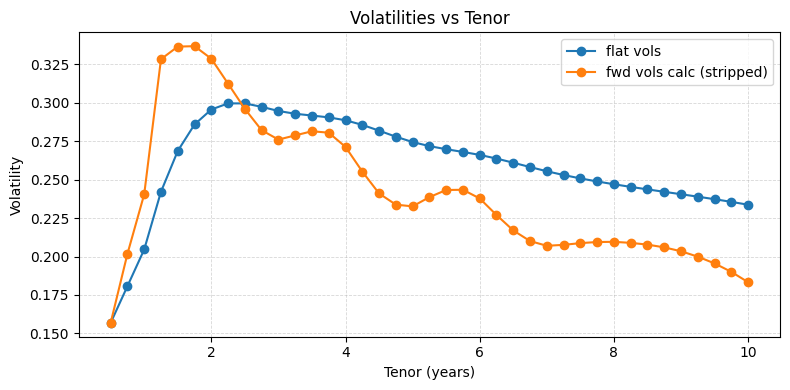

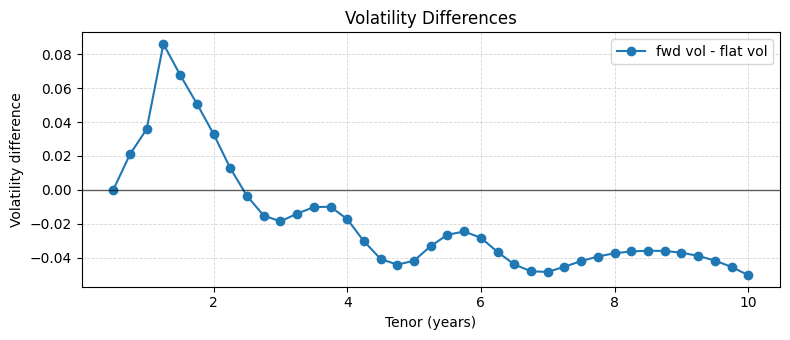

In [12]:
# plot flat vols, fwd vols and fwd vols calc
# Ensure sorted by tenor for clean lines
vp = caplets_till_10yr.copy()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(vp.index, vp['flat vols'], marker='o', linewidth=1.5, label='flat vols')
ax.plot(vp.index, vp['fwd vols calc'], marker='o', linewidth=1.5, label='fwd vols calc (stripped)')

ax.set_title('Volatilities vs Tenor')
ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Volatility')
ax.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

# plot differences
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(vp.index, vp['fwd vols calc'] - vp['flat vols'], marker='o', linewidth=1.5, label='fwd vol - flat vol')

ax.axhline(0.0, color='k', linewidth=1.0, alpha=0.6)
ax.set_title('Volatility Differences')
ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Volatility difference')
ax.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

-----